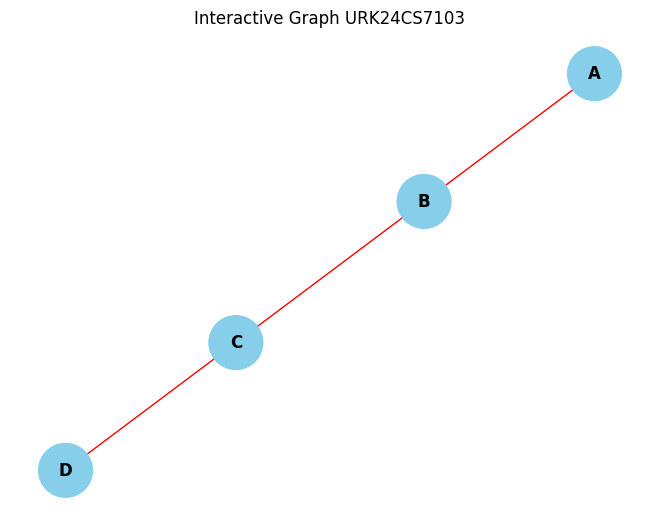

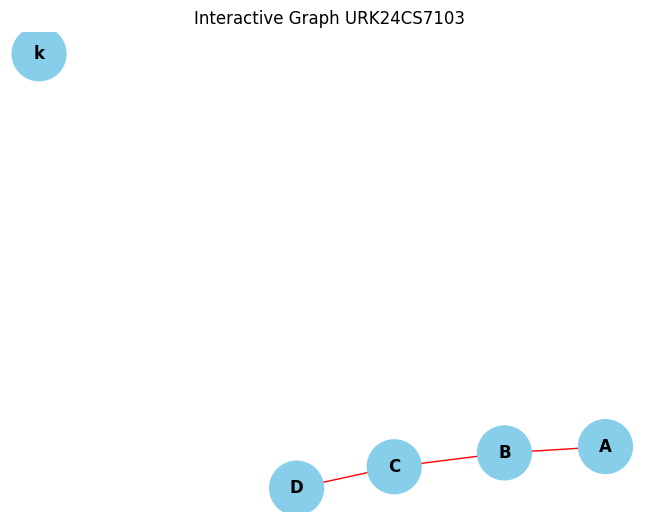

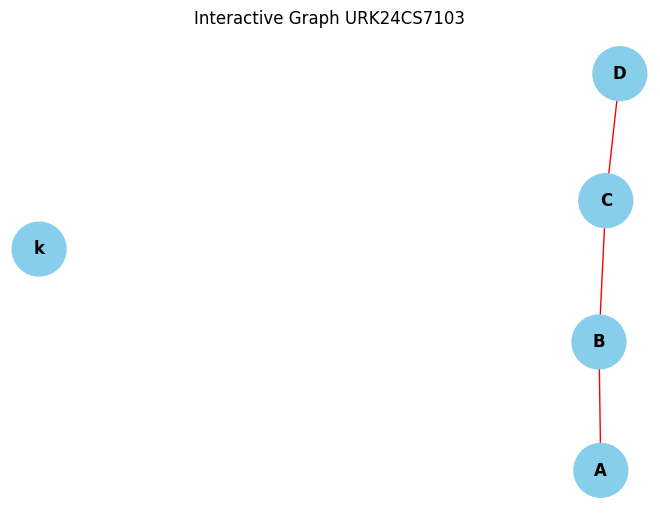

In [4]:
import tkinter as tk
from tkinter import simpledialog, messagebox
import networkx as nx
import matplotlib.pyplot as plt

def create_graph():
    G = nx.Graph()
    G.add_edges_from([('A', 'B'), ('B', 'C'), ('C', 'D')])
    return G

def visualize_graph(G, highlight_node=None):
    plt.clf()
    pos = nx.spring_layout(G)

    node_colors = ['yellow' if node == highlight_node else 'skyblue'
                   for node in G.nodes()]

    nx.draw(G, pos,
            with_labels=True,
            node_color=node_colors,
            node_size=1500,
            font_size=12,
            font_weight='bold',
            edge_color='red')

    plt.title("Interactive Graph URK24CS7103")
    plt.pause(0.1)   # important for Jupyter
    plt.show()

def add_node(G, root):
    new_node = simpledialog.askstring("Input", "Enter node name:", parent=root)
    if new_node:
        G.add_node(new_node)
        visualize_graph(G)

def remove_node(G, root):
    node = simpledialog.askstring("Remove", "Enter node to remove:", parent=root)
    if node in G:
        G.remove_node(node)
        visualize_graph(G)
    else:
        messagebox.showwarning("Error", f"Node '{node}' not found.")

def add_edge(G, root):
    n1 = simpledialog.askstring("Input", "First node:", parent=root)
    n2 = simpledialog.askstring("Input", "Second node:", parent=root)
    if n1 and n2:
        G.add_edge(n1, n2)
        visualize_graph(G)

def remove_edge(G, root):
    n1 = simpledialog.askstring("Remove", "First node of edge:", parent=root)
    n2 = simpledialog.askstring("Remove", "Second node of edge:", parent=root)
    if G.has_edge(n1, n2):
        G.remove_edge(n1, n2)
        visualize_graph(G)
    else:
        messagebox.showwarning("Error", "Edge not found.")

def search_node(G, root):
    node = simpledialog.askstring("Search", "Enter node to find:", parent=root)
    if node in G:
        messagebox.showinfo("Found", f"Node '{node}' exists in the graph!")
        visualize_graph(G, highlight_node=node)
    else:
        messagebox.showwarning("Not Found", f"Node '{node}' is not in the graph.")

def create_gui():
    root = tk.Tk()
    root.title("Graph Editor")
    root.geometry("250x300")

    G = create_graph()

    tk.Button(root, text="Visualize Graph",
              command=lambda: visualize_graph(G)).pack()
    tk.Button(root, text="Add Node",
              command=lambda: add_node(G, root)).pack()
    tk.Button(root, text="Remove Node",
              command=lambda: remove_node(G, root)).pack()
    tk.Button(root, text="Add Edge",
              command=lambda: add_edge(G, root)).pack()
    tk.Button(root, text="Remove Edge",
              command=lambda: remove_edge(G, root)).pack()
    tk.Button(root, text="Search Node",
              command=lambda: search_node(G, root)).pack()

    root.mainloop()

create_gui()